# Semana 7 - Actividad 7: Implementación de la Convolución de Matrices y su Aplicación en Imágenes con Padding y Stride en Google Colab


En esta actividad, las y los creadores de oportunidades implementarán la operación de convolución de matrices y su aplicación en imágenes, incorporando los conceptos de padding y stride. El propósito es comprender, con evidencia práctica, cómo se obtienen mapas de características y cómo las decisiones de padding/stride modifican dimensiones y la información preservada.

La actividad se desarrolla en Google Colab y deja evidencia reproducible en GitHub. No se espera un proyecto final de visión por computador, sino una práctica técnica clara que demuestre comprensión operacional.

Producto: un notebook ejecutable (.ipynb) en Google Colab, con evidencia organizada en GitHub.
El notebook debe evidenciar:
- (i) una implementación de convolución (manual con NumPy o una operación equivalente) sobre una matriz y/o imagen,
- (ii) al menos un ejemplo con padding y otro con stride, manteniendo condiciones comparables, y
- (iii) visualización o impresión verificable de resultados.
Debe incluir explicación breve (Markdown): qué representa la convolución y qué cambia al variar padding/stride.
Debe registrar resultados visibles (matrices/mapas/figuras) y una conclusión técnica breve basada en evidencia.
Comparación válida: mantener el mismo kernel/matriz base y cambiar únicamente padding o stride.

**Entregables (lo que debe quedar en GitHub)**
- Carpeta: week7/
- Notebook: .ipynb ejecutable (Run all sin errores).
- README.md breve con: objetivo, qué se comparó (padding/stride), evidencia principal (1–2 líneas) y cómo ejecutar.
- Conclusiones en el notebook: 3 puntos cortos basados en resultados.



**Propósito:** comprender operacionalmente la **convolución 2D** y cómo cambian los **mapas de características** cuando variamos **padding** y **stride**.

Este notebook evidencia:
- Implementación manual de convolución con NumPy
- Comparación válida cambiando solo padding o solo stride
- Resultados visibles (matrices/figuras)
- Matriz de confusión + 2 métricas + interpretación del error crítico


## 1) ¿Qué es la convolución y qué cambian padding/stride?

**Convolución 2D:** aplica un kernel (matriz pequeña de pesos) deslizándolo sobre una entrada (matriz o imagen), calculando sumas de productos locales en cada posición. El resultado es un **mapa de características** que resalta ciertos patrones (bordes, texturas, etc.) según el kernel utilizado.

**Padding:** agrega filas/columnas de ceros alrededor de la entrada antes de convolucionar.
- `padding=0` → la salida es más pequeña que la entrada (se pierden bordes).
- `padding=1` → permite que el kernel cubra los bordes, preservando más información y pudiendo mantener las dimensiones originales.

**Stride:** define cuántos píxeles salta el kernel en cada paso.
- `stride=1` → el kernel se mueve de uno en uno → mayor resolución en la salida.
- `stride=2` → el kernel salta de dos en dos → la salida tiene aproximadamente la mitad del tamaño → menor resolución pero mayor campo receptivo.

**Fórmula del tamaño de salida por dimensión:**

$$\text{Salida} = \left\lfloor\frac{N + 2P - K}{S}\right\rfloor + 1$$

Donde: $N$ = tamaño entrada, $P$ = padding, $K$ = tamaño kernel, $S$ = stride.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

SEED = 42
np.random.seed(SEED)
print('Librerías importadas correctamente.')


## 2) Implementación manual de convolución 2D (NumPy)

Implementación desde cero con soporte de padding y stride. No se usa ninguna función de convolución de librerías externas.


In [ ]:
def conv2d_numpy(x, k, stride=1, padding=0):
    x = np.array(x, dtype=float)
    k = np.array(k, dtype=float)

    Kh, Kw = k.shape

    if padding > 0:
        x_pad = np.pad(x, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        x_pad = x

    Hp, Wp = x_pad.shape
    out_h = (Hp - Kh) // stride + 1
    out_w = (Wp - Kw) // stride + 1

    out = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            hs = i * stride
            ws = j * stride
            window = x_pad[hs:hs+Kh, ws:ws+Kw]
            out[i, j] = np.sum(window * k)

    return out


## 3) Convolución sobre una matriz — Comparación de Padding

Se mantiene la misma matriz de entrada X y el mismo kernel K en todos los experimentos. Solo se varía el padding para observar el efecto aislado.


In [ ]:
X = np.array([
    [1, 2, 0, 0, 3],
    [4, 5, 0, 1, 2],
    [0, 0, 1, 2, 3],
    [1, 2, 3, 4, 0],
    [0, 1, 2, 0, 1],
])

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])

print('Matriz X (base):')
print(X)
print('Kernel K (fijo):')
print(K)

Y_no_pad = conv2d_numpy(X, K, stride=1, padding=0)
Y_pad1   = conv2d_numpy(X, K, stride=1, padding=1)

print('')
print('Salida SIN padding (stride=1):', Y_no_pad.shape)
print(Y_no_pad)

print('')
print('Salida CON padding=1 (stride=1):', Y_pad1.shape)
print(Y_pad1)


Matriz X (base):
[[1 2 0 0 3]
 [4 5 0 1 2]
 [0 0 1 2 3]
 [1 2 3 4 0]
 [0 1 2 0 1]]
Kernel K (fijo):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Salida SIN padding (stride=1): (3, 3)
[[ 4.  4. -7.]
 [ 1.  0. -1.]
 [-5. -3.  2.]]

Salida CON padding=1 (stride=1): (5, 5)
[[-7.  5.  6. -5.  1.]
 [-7.  4.  4. -7.  3.]
 [-7.  1.  0. -1.  7.]
 [-3. -5. -3.  2.  6.]
 [-3. -4. -1.  4.  4.]]


## 4) Ejemplo con stride (comparación válida)

Misma matriz y kernel, cambiando solo stride (padding fijo).


In [ ]:
Y_s1 = conv2d_numpy(X, K, stride=1, padding=1)
Y_s2 = conv2d_numpy(X, K, stride=2, padding=1)

print('Con padding=1:')
print('Stride=1 ->', Y_s1.shape)
print(Y_s1)
print('')
print('Stride=2 ->', Y_s2.shape)
print(Y_s2)


Con padding=1:
Stride=1 -> (5, 5)
[[-7.  5.  6. -5.  1.]
 [-7.  4.  4. -7.  3.]
 [-7.  1.  0. -1.  7.]
 [-3. -5. -3.  2.  6.]
 [-3. -4. -1.  4.  4.]]

Stride=2 -> (3, 3)
[[-7.  6.  1.]
 [-7.  0.  7.]
 [-3. -1.  4.]]


## 5) Aplicación en imágenes (Digits)

Usamos `load_digits` (imágenes 8x8). Convertimos a binario para CM:
- 0 = no crítico (0–4)
- 1 = crítico (5–9)


Imágenes: (1797, 8, 8)
Distribución binaria (0=no crítico, 1=crítico): [901 896]


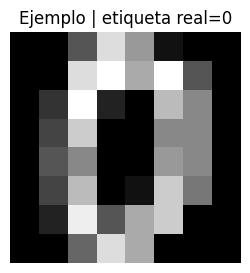

In [ ]:
digits = load_digits()
imgs = digits.images
labels = (digits.target >= 5).astype(int)

print('Imágenes:', imgs.shape)
print('Distribución binaria (0=no crítico, 1=crítico):', np.bincount(labels))

idx = 0
plt.figure(figsize=(3,3))
plt.imshow(imgs[idx], cmap='gray')
plt.title('Ejemplo | etiqueta real=' + str(labels[idx]))
plt.axis('off')
plt.show()


## 6) Mapas de características: padding vs stride (mismo kernel)

Se usa el **kernel de Sobel horizontal**, un filtro clásico para detección de bordes verticales:

  $$K_{Sobel} = \begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}$$


Comparación válida:
- A: pad=0, stride=1
- B: pad=1, stride=1 (solo cambia padding vs A)
- C: pad=1, stride=2 (solo cambia stride vs B)

Se aplica sobre **3 imágenes distintas** para mostrar que los efectos son generalizables.

Dimensiones:
Entrada: (8, 8)
A pad=0, s=1: (6, 6)
B pad=1, s=1: (8, 8)
C pad=1, s=2: (4, 4)


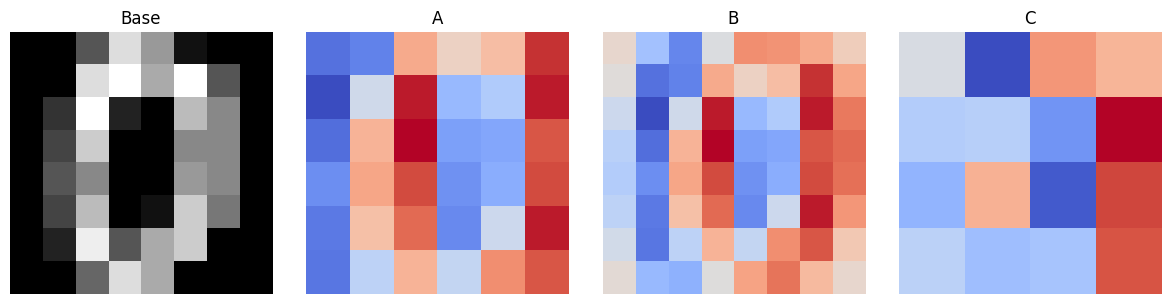


Mapa B (pad=1, stride=1) valores:
[[  0. -23. -41.  -5.  24.  23.  17.   5.]
 [ -3. -46. -42.  17.   3.  11.  42.  18.]
 [-10. -55.  -9.  45. -26. -19.  45.  29.]
 [-16. -47.  14.  47. -34. -32.  36.  32.]
 [-18. -39.  18.  38. -38. -30.  38.  31.]
 [-15. -44.  10.  32. -40. -10.  45.  22.]
 [ -8. -45. -15.  14. -13.  24.  36.   7.]
 [ -2. -26. -29.  -4.  19.  30.  12.   0.]]


In [ ]:
K_img = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1],
])

img0 = imgs[idx]
A = conv2d_numpy(img0, K_img, stride=1, padding=0)
B = conv2d_numpy(img0, K_img, stride=1, padding=1)
C = conv2d_numpy(img0, K_img, stride=2, padding=1)

print('Dimensiones:')
print('Entrada:', img0.shape)
print('A pad=0, s=1:', A.shape)
print('B pad=1, s=1:', B.shape)
print('C pad=1, s=2:', C.shape)

fig, ax = plt.subplots(1, 4, figsize=(12,3))
ax[0].imshow(img0, cmap='gray'); ax[0].set_title('Base'); ax[0].axis('off')
ax[1].imshow(A, cmap='coolwarm'); ax[1].set_title('A'); ax[1].axis('off')
ax[2].imshow(B, cmap='coolwarm'); ax[2].set_title('B'); ax[2].axis('off')
ax[3].imshow(C, cmap='coolwarm'); ax[3].set_title('C'); ax[3].axis('off')
plt.tight_layout(); plt.show()

print('')
print('Mapa B (pad=1, stride=1) valores:')
print(B)


## 7) Preprocesamiento/partición (evidencia)

- **Normalización:** dividimos los píxeles entre 16.0 (rango original del dataset) para llevarlos al intervalo [0, 1].
- **Partición:** 75% entrenamiento / 25% prueba, estratificada para preservar el balance de clases.

In [ ]:
X_imgs = imgs / 16.0
X_train, X_test, y_train, y_test = train_test_split(
    X_imgs, labels, test_size=0.25, random_state=SEED, stratify=labels
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Distribución train:', np.bincount(y_train))
print('Distribución test :', np.bincount(y_test))


Train: (1347, 8, 8) Test: (450, 8, 8)
Distribución train: [675 672]
Distribución test : [226 224]


# 8) Extracción de características con convolución y clasificación

Se aplica el kernel de Sobel sobre cada imagen para extraer un mapa de características, que luego se aplana como vector de entrada a un clasificador lineal (Regresión Logística).

**¿Por qué funciona?** La convolución transforma cada imagen en una representación que resalta los bordes verticales. Estas características estructurales permiten al clasificador distinguir entre clases con mayor facilidad que usando los píxeles crudos directamente.


In [ ]:
def extract_features(images, kernel, stride=1, padding=1):
    feats = []
    for im in images:
        fm = conv2d_numpy(im, kernel, stride=stride, padding=padding)
        feats.append(fm.flatten())
    return np.vstack(feats)

Xtr = extract_features(X_train, K_img, stride=1, padding=1)
Xte = extract_features(X_test,  K_img, stride=1, padding=1)
print('Features train:', Xtr.shape)
print('Features test :', Xte.shape)

clf = LogisticRegression(max_iter=2000, random_state=SEED)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

acc = accuracy_score(y_test, pred)
rec = recall_score(y_test, pred, pos_label=1)
print('')
print('Accuracy:', round(acc, 4))
print('Recall (Crítico=1):', round(rec, 4))


Features train: (1347, 64)
Features test : (450, 64)

Accuracy: 0.8778
Recall (Crítico=1): 0.8884


## 9) Matriz de confusión + 2 métricas (explicación)

Reportamos:
1) **Accuracy** (global)
2) **Recall** para **Crítico (1)** (cuántos críticos detectamos)


CM (filas=real, columnas=predicho) [0=no crítico, 1=crítico]:
[[196  30]
 [ 25 199]]


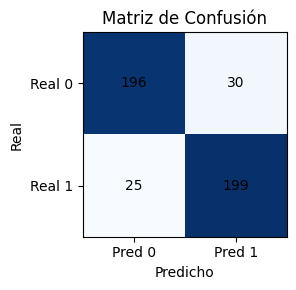


Métricas (2):
Accuracy total: 0.8778
Recall clase Crítico (1): 0.8884


In [ ]:
cm = confusion_matrix(y_test, pred, labels=[0,1])
print('CM (filas=real, columnas=predicho) [0=no crítico, 1=crítico]:')
print(cm)

plt.figure(figsize=(4,3))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['Real 0', 'Real 1'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout(); plt.show()

print('')
print('Métricas (2):')
print('Accuracy total:', round(acc, 4))
print('Recall clase Crítico (1):', round(rec, 4))


## 10) Interpretación del error crítico

**Error crítico:** Falso Negativo (FN) = Crítico real (1) → Predicho No crítico (0).

En Contact Center suele ser más grave porque un crítico requiere priorización/escalamiento y puede impactar SLA y riesgo.


In [ ]:
TN, FP, FN, TP = cm.ravel()
print('TN=', TN, 'FP=', FP, 'FN=', FN, 'TP=', TP)
fnr = FN / (FN + TP) if (FN + TP) > 0 else 0
print('Tasa de falsos negativos (Crítico):', round(fnr, 4))


TN= 196 FP= 30 FN= 25 TP= 199
Tasa de falsos negativos (Crítico): 0.1116


### 11) Conclusiones (3 puntos)

1. **Padding preserva información de bordes y dimensiones:** con `padding=1` la salida mantiene el mismo tamaño que la entrada (8×8 → 8×8), mientras que `padding=0` reduce las dimensiones (8×8 → 6×6), perdiendo información de los píxeles perimetrales. En imágenes pequeñas como las de 8×8, esta pérdida es especialmente relevante.

2. **Stride controla la resolución del mapa de características:** aumentar el stride de 1 a 2 reduce las dimensiones de salida aproximadamente a la mitad (8×8 → 4×4 con padding=1), disminuyendo el costo computacional pero sacrificando detalle espacial. El patrón detectado es el mismo, pero con menor granularidad.

3. **El error más crítico es el Falso Negativo:** con FNR = 11.16%, el modelo no detecta aproximadamente 1 de cada 9 casos críticos. En Contact Center, estos casos no recibirían escalamiento ni priorización, con impacto directo en SLA y riesgo operacional. Reducir los FN mediante un umbral de clasificación más bajo o mejores features convolucionadas es la palanca de mejora más importante en este dominio.

---
**Cómo ejecutar:** abrir en Google Colab → `Entorno de ejecución` → `Ejecutar todo` (sin errores esperados).
